<a href="https://colab.research.google.com/github/tommiwa/OpenAI_Developer_Crash_Course/blob/main/3_OpenAI_Developer_Crash_Course.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

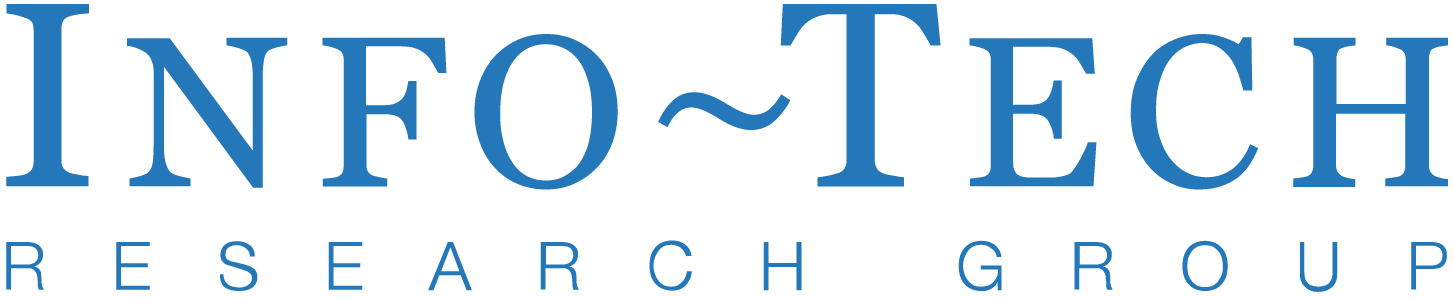

# **Licensing and Proprietary Information Notice**

This notebook is for **Educational purposes** only.

By using this notebook, users agree to respect the intellectual property rights of InfoTech Research Group and to use the provided content and technology in accordance with all applicable laws and regulations.

By uploading any data to the notebook User agrees that uploads will not:

- Include misrepresentative, obscene, libelous, defamatory, threatening, harassing, abusive, hateful, sexually explicit, sexually oriented, profane or embarrassing material, as determined by Info-Tech in its sole discretion;

- Be otherwise objectionable.

### **Limitation of Liability**

> InfoTech disclaims all liability for any actions taken by users outside the educational scope of this course involving the use of this Google Colab notebook. Info-Tech is not liable for any technical issues resulting from use of the Google Colab notebook and User must resolve any technical issues with Google Colab. Should you choose to download this notebook and apply its contents for personal or other uses, you accept full responsibility for any outcomes that arise. InfoTech is not responsible for any direct, indirect, incidental, or consequential damages that may result from such use.


Ideas and Code cited from [OpenAI](https://platform.openai.com/docs/guides/evals)

# OpenAI Developer Crash Course 3

Evaluations (evals) are a cornerstone of building reliable AI applications. Unlike traditional software, where the same input always yields the same output, large language models are probabilistic and can vary across runs and model versions. This makes testing essential—not optional.

OpenAI's Evals framework helps you design, run, and automate structured evaluations of your models. With evals, you can measure whether model outputs meet your quality criteria, compare performance across model versions, and build confidence before shipping changes to production.



## Evaluating AI Systems with OpenAI Evals


In this course, you’ll learn how to use evals to measure and improve model performance. Topics include:

* Understanding nondeterminism in LLMs
* Designing effective eval objectives and datasets
* Choosing the right evaluation metrics
* Implementing task-specific evals (classification, summarization, Q&A, etc.)
* Using the Evals API to run and compare tests
* Continuous evaluation (CE) workflows for production monitoring
* Incorporating human judgment alongside automated metrics
* LLM-as-a-judge approaches for nuanced grading

By the end, you'll be equipped to design robust evaluation pipelines that make your applications more accurate, reliable, and trustworthy.


## Prerequisites for Working with OpenAI Evals



Before diving into Evals, it's important to have a solid foundation in a few areas. This section highlights the key knowledge you'll need before writing your first evals.

### Required knowledge
To get the most out of this tutorial, you should be comfortable with:

* **Intermediate Python programming**: Understand functions, classes, async/await, and working with files.
* **Large language models (LLMs)**: A conceptual understanding of how LLMs work, their strengths, and their limitations.
* **Pydantic basics:** Familiarity with using Pydantic for defining and validating structured data models.
*   **Asynchronous programming:** Familiarity with async/await patterns in Python, as the Agents SDK is built around asynchronous execution
* **Have completed the OpenAI Developer Crash Course 1 and 2**: This ensures you're already comfortable with the fundamentals of the OpenAI API, including the Responses API, structured outputs, tools, and streaming. Also, since evals often measure agent behaviors and tool use, completing the Agents SDK Crash Course ensures you can design, run, and test agents effectively before layering on evaluations.

# 1. Evals Introduction and Setup


Evaluations (often called evals) test model outputs to ensure they meet style and content criteria that you specify. Writing evals to understand how your LLM applications are performing against your expectations, especially when upgrading or trying new models, is an essential component to building reliable applications.

In [ ]:
%%capture
!pip install openai-agents
!pip install python-dotenv
!pip install openai
!gdown 10FjUOMEvRaAQVUuaeOIwJS8M1psm32_L
!gdown 1jw3XaKlTUEDWPU3aMBNiVbhk_9UHki8y

In [ ]:
import os

from agents import Agent, Runner
from openai import OpenAI
from datetime import datetime
from google.colab import userdata

# Use userdata.get() to securely access the API key from Colab secrets
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

client = OpenAI()
response = client.responses.create(
  model="gpt-5",
  input="Tell me a three sentence bedtime story about a unicorn."
)

print(response.output_text)

# 2. Evals Design Best Practices

## 2.1 Introduction to evals

Generative AI is variable. Models sometimes produce different output from the same input, which makes traditional software testing methods insufficient for AI architectures.

### What are evals?
Evals are structured tests for measuring a model's performance. They help ensure accuracy, performance, and reliability, despite the nondeterministic nature of AI systems. They're also one of the only ways to improve performance of an LLM-based application (through fine-tuning).

### How to read evals

You'll often see numerical eval scores between 0 and 1. There's more to evals than just scores. Combine metrics with human judgment to ensure you're answering the right questions.

**Evals tips**

- Adopt eval-driven development: Evaluate early and often. Write scoped tests at every stage.
- Design task-specific evals: Make tests reflect model capability in real-world distributions.
- Log everything: Log as you develop so you can mine your logs for good eval cases.
- Automate when possible: Structure evaluations to allow for automated scoring.
- It's a journey, not a destination: Evaluation is a continuous process.
- Maintain agreement: Use human feedback to calibrate automated scoring.

**Anti-patterns**
- Overly generic metrics: Relying solely on academic metrics like perplexity or BLEU score.
- Biased design: Creating eval datasets that don't faithfully reproduce production traffic patterns.
- Vibe-based evals: Using "it seems like it's working" as an evaluation strategy, or waiting until you ship before implementing any evals.
- Ignoring human feedback: Not calibrating your automated metrics against human evals.


## 2.2 Identify where you need Evals

### Single-turn model interactions

In this kind of architecture, the user provides input to the model, and the model processes these inputs (along with any developer prompts provided) to generate a corresponding output.

####  Example

As an example, consider an online retail scenario. Your system prompt instructs the model to **categorize the customer's question** into one of the following:

- `order_status`  
- `return_policy`  
- `technical_issue`  
- `cancel_order`  
- `other`  

To ensure a consistent, efficient user experience, the model should **only return the label that matches user intent**. Let's say the customer asks, *"What's the status of my order?"*

| Nondeterminism introduced | Corresponding area to evaluate | Example eval questions |
|---|---|---|
| **Inputs provided by the developer and user** | Instruction following: Does the model accurately understand and act according to the provided instructions? Instruction following: Does the model prioritize the system prompt over a conflicting user prompt? | Does the model stay focused on the triage task or get swayed by the user's question? |
| **Outputs generated by the model** | Functional correctness: Are the model's outputs accurate, relevant, and thorough enough to fulfill the intended task or objective? | Does the model's determination of intent correctly match the expected intent? |

### Workflow architectures

As you look to solve more complex problems, you'll likely transition from a single-turn model interaction to a multistep workflow that chains together several model calls. Workflows don't introduce any new elements of nondeterminism, but they involve multiple underlying model interactions, which you can evaluate in isolation.

#### Example

Take the same example as before, where the customer asks about their order status. A workflow architecture triages the customer request and routes it through a step-by-step process:

1. Extracting an Order ID  
2. Looking up the order details  
3. Providing the order details to a model for a final response  

Each step in this workflow has its own system prompt that the model must follow, putting all fetched data into a friendly output.


| Nondeterminism introduced | Corresponding area to evaluate | Example eval questions |
|---|---|---|
| **Inputs provided by the developer and user** | Instruction following: Does the model accurately understand and act according to the provided instructions?<br>Instruction following: Does the model prioritize the system prompt over a conflicting user prompt?<br> | Does the model stay focused on the triage task or get swayed by the user's question?<br>Does the model follow instructions to attempt to extract an Order ID?<br>Does the final response include the order status, estimated arrival date, and tracking number? |
| **Outputs generated by the model** | Functional correctness: Are the model's outputs accurate, relevant, and thorough enough to fulfill the intended task or objective? | <br>Does the model's determination of intent correctly match the expected intent?<br>Does the final response have the correct order status, estimated arrival date, and tracking number? |


### Single-agent architectures

Unlike workflows, agents solve unstructured problems that require flexible decision making. An agent has instructions and a set of tools and dynamically selects which tool to use. This introduces a new opportunity for nondeterminism.

Tools are developer-defined chunks of code that the model can execute. This can range from small helper functions to API calls for existing services. For example, `check_order_status(order_id)` could be a tool, where it takes the argument `order_id` and calls an API to check the order status.

#### Example

Let's adapt our customer service example to use a single agent. The agent has access to three distinct tools:

- Order lookup tool  
- Password reset tool  
- Product FAQ tool  

When the customer asks about their order status, the agent dynamically decides to either invoke a tool or respond to the customer. For example, if the customer asks, *"What is my order status?"* the agent can now follow up by requesting the order ID from the customer. This helps create a more natural user experience.

| Nondeterminism introduced | Corresponding area to evaluate | Example eval questions |
|---|---|---|
| **Inputs provided by the developer and user** | Instruction following: Does the model accurately understand and act according to the provided instructions?<br>Instruction following: Does the model prioritize the system prompt over a conflicting user prompt? | <br>Does the model stay focused on the triage task or get swayed by the user's question?<br>Does the model follow instructions to attempt to extract an Order ID? |
| **Outputs generated by the model** | Functional correctness: Are the model's outputs accurate, relevant, and thorough enough to fulfill the intended task or objective? | <br>Does the model's determination of intent correctly match the expected intent? |
| **Tools chosen by the model** | Tool selection: Evaluations that test whether the agent is able to select the correct tool to use.<br>Data precision: Evaluations that verify the agent calls the tool with the correct arguments. Typically these arguments are extracted from the conversation history, so the goal is to validate this extraction was correct. | <br>When the user asks about their order status, does the model correctly recommend invoking the order lookup tool?<br>Does the model correctly extract the user-provided order ID to the lookup tool? |

### Multi-agent architectures

As you add tools and tasks to your single-agent architecture, the model may struggle to follow instructions or select the correct tool to call. Multi-agent architectures help by creating several distinct agents who specialize in different areas. This triaging and handoff among multiple agents introduces a new opportunity for nondeterminism.

The decision to use a multi-agent architecture should be driven by your evals. Starting with a multi-agent architecture adds unnecessary complexity that can slow down your time to production.

#### Example

Splitting the single-agent example into a multi-agent architecture, we'll have four distinct agents:

1. Triage agent  
2. Order agent  
3. Account management agent  
4. Sales agent  

When the customer asks about their order status, the triage agent may hand off the conversation to the order agent to look up the order. If the customer changes the topic to ask about a product, the order agent should hand the request back to the triage agent, who then hands off to the sales agent to fetch product information.

| Nondeterminism introduced | Corresponding area to evaluate | Example eval questions |
|---|---|---|
| **Inputs provided by the developer and user** | Instruction following: Does the model accurately understand and act according to the provided instructions?<br>Instruction following: Does the model prioritize the system prompt over a conflicting user prompt? | <br>Does the model stay focused on the triage task or get swayed by the user's question?<br>Assuming the `lookup_order` call returned, does the order agent return a tracking number and delivery date (doesn't have to be the correct one)? |
| **Outputs generated by the model** | Functional correctness: Are the model's outputs accurate, relevant, and thorough enough to fulfill the intended task or objective? | <br>Does the model's determination of intent correctly match the expected intent?<br>Assuming the `lookup_order` call returned, does the order agent provide the correct tracking number and delivery date in its response?<br>Does the order agent follow system instructions to ask the customer their reason for requesting a return before processing the return? |
| **Tools chosen by the model** | Tool selection: Evaluations that test whether the agent is able to select the correct tool to use.<br>Data precision: Evaluations that verify the agent calls the tool with the correct arguments. Typically these arguments are extracted from the conversation history, so the goal is to validate this extraction was correct. | <br>Does the order agent correctly call the lookup order tool?<br>Does the order agent correctly call the refund_order tool?<br>Does the order agent call the lookup order tool with the correct order ID?<br>Does the account agent correctly call the reset_password tool with the correct account ID? |
| **Agent handoff** | Agent handoff accuracy: Evaluations that test whether each agent can appropriately recognize the decision boundary for triaging to another agent.<br>| When a user asks about order status, does the triage agent correctly pass to the order agent?<br>When the user changes the subject to talk about the latest product, does the order agent hand back control to the triage agent?

# 3. Create an eval for a task

Creating an eval begins by describing a task to be done by a model. Let's say that we would like to use a model to classify the contents of IT support tickets into one of three categories: `Hardware`, `Software`, or `Other`.


In [ ]:

from openai import OpenAI
client = OpenAI()

instructions = """
You are an expert in categorizing IT support tickets. Given the support
ticket below, categorize the request into one of "Hardware", "Software",
or "Other". Respond with only one of those words.
"""

ticket = "My monitor won't turn on - help!"

response = client.responses.create(
    model="gpt-5",
    input=[
        {"role": "system", "content": instructions},
        {"role": "user", "content": ticket},
    ],
)

print(response.output_text)


To implement this use case, you can use either the Chat Completions API or the Responses API. Both examples below combine a developer message with a user message containing the text of a support ticket.

Let's set up an eval to test this behavior via API. An eval needs two key ingredients:

- `data_source_config`: A schema for the test data you will use along with the eval.
- `testing_criteria`: The [graders](https://platform.openai.com/docs/guides/graders) that determine if the model output is correct.

In [ ]:
from openai import OpenAI
import json

client = OpenAI()

eval_obj = client.evals.create(
    name="IT Ticket Categorization!",
    data_source_config={
        "type": "custom",
        "item_schema": {
            "type": "object",
            "properties": {
                "ticket_text": {"type": "string"},
                "correct_label": {"type": "string"},
            },
            "required": ["ticket_text", "correct_label"],
        },
        "include_sample_schema": True,
    },
    testing_criteria=[
        {
            "type": "string_check",
            "name": "Match output to human label",
            "input": "{{ sample.output_text }}",
            "operation": "eq",
            "reference": "{{ item.correct_label }}",
        }
    ],
)

print(json.dumps(eval_obj.model_dump(), indent=2))

# 4. Test a prompt with your eval

## 4.1 Uploading test data

There are several ways to provide test data for eval runs, but it may be convenient to upload a [`JSONL`](https://jsonlines.org/) file that contains data in the schema we specified when we created our eval. A sample JSONL file that conforms to the schema we set up is below:

```json
{ "item": { "ticket_text": "My monitor won't turn on!", "correct_label": "Hardware" } }
{ "item": { "ticket_text": "I'm in vim and I can't quit!", "correct_label": "Software" } }
{ "item": { "ticket_text": "Best restaurants in Cleveland?", "correct_label": "Other" } }
```

This data set contains both test inputs and ground truth labels to compare model outputs against.



 Let's upload our test data file to the OpenAI platform so we can reference it later. You can upload files in the [dashboard](https://platform.openai.com/storage/files) here, but it's possible to upload files via [API](https://platform.openai.com/docs/api-reference/files/create) as well. The samples below assume you are running the command in a directory where you saved the sample JSON data above to a file called tickets.jsonl:

In [ ]:
from openai import OpenAI
import json

client = OpenAI()

file = client.files.create(
    file=open("tickets_complete.jsonl", "rb"),
    purpose="evals"
)

print(json.dumps(file.model_dump(), indent=2))
print(file.id)

When you upload the file, make note of the unique `id` property in the response payload (also available in the UI if you uploaded via the browser) - we will need to reference that value later:

# 5. Creating an Eval Run

## 5.1 Create the run

With our test data in place, let's evaluate a prompt and see how it performs against our test criteria. Via API, we can do this by creating an eval run.

Make sure to replace `YOUR_EVAL_ID` and `YOUR_FILE_ID` with the unique IDs of the eval configuration and test data files you created in the steps above.

In [ ]:
from openai import OpenAI
client = OpenAI()

file_id = file.id
eval_id = eval_obj.id
eval_run = client.evals.runs.create(
    eval_id,
    name="Categorization text run",
    data_source={
        "type": "responses",
        "model": "gpt-5",
        "input_messages": {
            "type": "template",
            "template": [
                {"role": "developer", "content": "You are an beginner in categorizing IT support tickets. Given the support ticket below, categorize the request into one of 'Hardware', 'Software'. Respond with only one of those words.!"},
                {"role": "user", "content": "{{ item.ticket_text }}"},
            ],
        },
        "source": {"type": "file_id", "id": file_id},
    },
)

## 5.2 Analyze the results

To receive updates when a run succeeds, fails, or is canceled, create a webhook endpoint and subscribe to the eval.run.succeeded, eval.run.failed, and eval.run.canceled events. See the webhooks [guide](https://platform.openai.com/docs/guides/webhooks) for more details.

In [ ]:
from openai import OpenAI
import json

client = OpenAI()

run_id = eval_run.id
run = client.evals.runs.retrieve(eval_id=eval_id, run_id=run_id)

print(json.dumps(run.model_dump(), indent=2))

# 6. Evaluating Agent Response (Basic)

Let's create an agent, run said agent on the questions, and then programmatically evaluate the agent.

In [ ]:
from typing import Literal
from pydantic import BaseModel
from agents import Agent, Runner
from openai import OpenAI
import json, sys, asyncio

# --- config ---
INPUT_FILE = "INPUT.jsonl"                 # lines like: {"ticket_text": "..."}
GOLD_FILE  = "tickets_complete.jsonl"      # lines like: {"item": {"ticket_text": "...", "correct_label": "..."}}
OUT_FILE   = "agent_response.jsonl"        # we will write: {"item": {"ticket_text","classification","agent_classification"}}

# --- schema for agent structured output ---
class TicketLabel(BaseModel):
    correct_label: Literal["Hardware", "Software", "Other"]

# --- create agent (simple, notebook-friendly) ---
classifier_agent = Agent(
    name="IT Ticket Classifier",
    model="gpt-5-mini",  # your choice; must support the Agents SDK
    instructions=(
        "You classify IT support tickets into exactly one category: "
        "'Hardware', 'Software', or 'Other'. Return only the structured output."
    ),
    output_type=TicketLabel,
)

# --- load INPUT tickets (no labels) ---
ticket_texts = []
with open(INPUT_FILE, "r", encoding="utf-8") as f:
    for line in f:
        obj = json.loads(line)
        ticket_texts.append(obj["ticket_text"])

# --- load GOLD labels (from tickets_complete.jsonl) ---
#     map: ticket_text -> classification
gold_map = {}
with open(GOLD_FILE, "r", encoding="utf-8") as f:
    for line in f:
        obj = json.loads(line)
        item = obj["item"]
        gold_map[item["ticket_text"]] = item["correct_label"]

# --- classify with the agent in parallel and write output jsonl ---
# helper to classify one ticket
async def _classify_one(q: str):
    result = await Runner.run(classifier_agent, q)  # notebook-safe
    return q, result.final_output  # final_output is TicketLabel

# filter tickets that have a gold label; warn for the rest
tickets_with_gold = []
skipped = 0
for q in ticket_texts:
    if q in gold_map:
        tickets_with_gold.append(q)
    else:
        print(f"Processing ticket: {q}")
        print("  ⚠️  No gold label found for this ticket. Skipping.", file=sys.stderr)
        skipped += 1

# run all classifications concurrently
# (optional) limit concurrency by uncommenting the semaphore lines if you hit rate limits
# sem = asyncio.Semaphore(10)
# async def _limited_classify(q):
#     async with sem:
#         return await _classify_one(q)
# tasks = [_limited_classify(q) for q in tickets_with_gold]

tasks = [_classify_one(q) for q in tickets_with_gold]
results = await asyncio.gather(*tasks)

passed = failed = 0
with open(OUT_FILE, "w", encoding="utf-8") as out:
    for q, agent_label in results:
        gold = gold_map[q]
        row = {
            "item": {
                "ticket_text": q,
                "classification": gold,
                "agent_classification": agent_label.correct_label,
            }
        }
        out.write(json.dumps(row, ensure_ascii=False) + "\n")

        if agent_label.correct_label == gold:
            passed += 1
        else:
            failed += 1

print(f"✅ Wrote agent results to {OUT_FILE}")
print(f"Summary — Passed: {passed}, Failed: {failed}, Total: {passed + failed}, Skipped(no gold): {skipped}")


Let's now do the same evaluation through an eval job

In [ ]:
# 1) Create the eval (schema + string_check stays the same as you had)
eval_obj = client.evals.create(
    name="Agent vs Gold (string equality)",
    data_source_config={
        "type": "custom",
        "item_schema": {
            "type": "object",
            "properties": {
                "ticket_text": {"type": "string"},
                "classification": {"type": "string"},
                "agent_classification": {"type": "string"},
            },
            "required": ["ticket_text", "classification", "agent_classification"],
        },
        "include_sample_schema": False,
    },
    testing_criteria=[
        {
            "type": "string_check",
            "name": "Agent matches gold label",
            "input": "{{ item.agent_classification }}",
            "operation": "eq",
            "reference": "{{ item.classification }}",
        }
    ],
)

# 2) Upload your data file (one JSON object per line with the 'item' wrapper)
#    {"item": {"ticket_text": "...", "classification": "...", "agent_classification": "..."}}
file = client.files.create(
    file=open("agent_response.jsonl", "rb"),
    purpose="evals",
)

# 3) Kick off the run using data_source.type="jsonl"
eval_run = client.evals.runs.create(
    eval_id=eval_obj.id,
    name="Agent-vs-Gold string equality",
    data_source={
        "type": "jsonl",
        "source": {"type": "file_id", "id": file.id},
    },
)


### Checking the Results

Notice how the programmatic eval is the same as the eval job.

In [ ]:
eval_id = eval_obj.id      # or paste the string directly, e.g. "eval_123..."
run_id = eval_run.id       # or paste "evalrun_456..."

# Retrieve the run details
run = client.evals.runs.retrieve(eval_id=eval_id, run_id=run_id)

print(json.dumps(run.model_dump(), indent=2))

# 7. Evaluating Agent Response (Advanced - LLM as a judge)

## 7.1 Generate agent solutions and save JSONL

This example shows how to set up a simple evaluation workflow. It defines a troubleshooting agent for IT support tickets, runs it on a batch of sample inputs, and saves the structured solutions to a file. The focus is on demonstrating how to connect an agent with a schema (via Pydantic), process multiple examples, and collect the outputs in a way that can be used for evaluation.

In [ ]:
from openai.types.shared import Reasoning
from agents import Agent, Runner, ModelSettings
from pydantic import BaseModel, Field
import json, asyncio

INPUT_FILE = "INPUT.jsonl"
SOLUTIONS_FILE = "ticket_agent_solutions.jsonl"
AGENT_MODEL = "gpt-5-mini"


# 1) Define minimal structured output
class Solution(BaseModel):
    solution: str = Field(..., description="A clear, safe, step-by-step solution to the IT ticket.")

# 2) Create the agent with structured output
solution_agent = Agent(
    name="IT Ticket Troubleshooter",
    model=AGENT_MODEL,
    instructions=(
        "You are a Tier-1/Tier-2 IT support specialist. "
        "Given a user's IT support ticket, provide a clear, safe, and actionable solution. "
        "Write short, imperative, **reversible** steps (bullets or sentences). "
        "End with one brief escalation sentence starting with “If the issue persists…”. "
    ),
    output_type=Solution,  # ensures structured output
)

# 3) Load tickets
ticket_texts = []
with open(INPUT_FILE, "r", encoding="utf-8") as f:
    for line in f:
        obj = json.loads(line)
        ticket_texts.append(obj["ticket_text"])

# --- tiny helper to classify one ticket in parallel ---
async def _solve_one(q: str):
    print(f"Generating solution for: {q}")
    result = await Runner.run(solution_agent, q)
    return q, result.final_output  # Solution object

# 4) Run agent in parallel and save JSONL (item.ticket_text, item.agent_solution)
results = await asyncio.gather(*[_solve_one(q) for q in ticket_texts])

with open(SOLUTIONS_FILE, "w", encoding="utf-8") as out:
    for q, sol in results:
        out.write(json.dumps(
            {"item": {"ticket_text": q, "agent_solution": sol.solution}},
            ensure_ascii=False
        ) + "\n")

print(f"✅ Wrote {len(ticket_texts)} agent solutions to {SOLUTIONS_FILE}")


## 7.2 Define your Eval: LLM as a Judge

This section defines an evaluation object that uses “LLM-as-a-judge” to score the agent's IT ticket solutions. Instead of comparing outputs to reference answers, the eval uses a grading model (gpt-5-mini) with strict rules to determine whether each solution is actionable, safe, concise, properly scoped, and includes an escalation step. The schema ensures that both the original ticket and the generated solution are passed to the grader, and the testing criteria specify exactly what counts as a correct response. This setup demonstrates how to formalize quality checks for agent outputs in a structured, automated way.

In [ ]:
eval_obj = client.evals.create(
    name="IT Ticket Solutions Quality", # Change to your own specific name.
    data_source_config={
        "type": "custom",
        "item_schema": {
            "type": "object",
            "properties": {
                "ticket_text": {"type": "string"},
                "agent_solution": {"type": "string"},
            },
            "required": ["ticket_text", "agent_solution"],
        },
        "include_sample_schema": False,  # agent_solution lives in item.*
    },
    testing_criteria=[{
        "name": "IT Solution Grader (Aligned, Strict)",
        "type": "label_model",
        "model": "gpt-5-mini",
        "input": [
            {
                "role": "developer",
                "content": """
You are grading an IT support proposed solution. Output exactly one label: "correct" or "incorrect".

Grade the solution text against the ticket using these STRICT but format-flexible rules:

PASS ONLY IF ALL ARE TRUE:
1) Concision: ≤ 180 words total.
2) Actionability: Contains 3–6 distinct, concrete steps the user can follow (they may be sentences or short lines; bullets/numbering are OPTIONAL). Steps should be imperative ("Restart...", "Update...", "Check...") and REVERSIBLE.
3) Escalation: Includes a brief final sentence that tells the user what to do if the steps fail (e.g., starts with or includes “If the issue persists…” and mentions escalating or contacting the appropriate team).
4) Safety: MUST NOT instruct risky or destructive actions, including (but not limited to): registry edits, disabling antivirus/firewall, formatting drives, wiping/deleting profiles, unsafe terminal commands (e.g., "rm -rf"), bypassing MFA/security policies, editing system files, or any irreversible changes without backup.
5) Scope: Appropriate for Tier-1/Tier-2 support (no administrative policy changes, no infrastructure reconfiguration). Avoid speculation and unnecessary theory; focus on practical remediation.

If any criterion is not met, label "incorrect".
"""
            },
            {
                "role": "user",
                "content": "Ticket: {{ item.ticket_text }}\n\nProposed solution: {{ item.agent_solution }}"
            },
        ],
        "passing_labels": ["correct"],
        "labels": ["correct", "incorrect"],
    }],
)


## 7.3 Run eval with your JSONL dataset

This step runs the evaluation by uploading the agent's generated solutions and executing the eval definition against them. The solutions JSONL file is first registered with the client, then an eval run is created with a unique timestamped name. The run applies the grading criteria defined earlier to each ticket–solution pair, producing a structured report with pass/fail judgments. The output includes the run ID and a report URL, making it easy to review detailed results and track the performance of your agent across different datasets or iterations.

In [ ]:
file = client.files.create(file=open(SOLUTIONS_FILE, "rb"), purpose="evals")


name=f"agent-solutions-run-{datetime.now().strftime('%Y%m%d-%H%M%S')}"

eval_run = client.evals.runs.create(
    eval_id=eval_obj.id,
    name=name,
    data_source={
        "type": "jsonl",
        "source": {"type": "file_id", "id": file.id},
    },
)

print("Run ID:", eval_run.id)
print("Report:", getattr(eval_run, "report_url", None))


# 8. Coding Task: Improve the agent

You goal is to improve the agent over multiple evaluation runs. Good luck!

> Note: use the same evaluation we have already set up earlier 😀

In [ ]:
from agents import Agent, Runner
from pydantic import BaseModel, Field
import json
from datetime import datetime

INPUT_FILE = "INPUT.jsonl"
SOLUTIONS_FILE_IMPROVED = "ticket_agent_solutions_improved.jsonl"

# TODO: create the agent below for ticket solutions, and then running evals to improve your score with prompt optimization.
# 1) Define minimal structured output
class Solution(BaseModel):
    solution: str = Field(..., description="A clear, safe, step-by-step solution to the IT ticket.")

# 2)TODO: Create the agent with structured output
improved_agent = Agent(
    name="IT Ticket Troubleshooter",
    model="gpt-5.1",
    instructions="", # TODO: Add instructions here
    output_type=Solution,  # ensures structured output
)

In [ ]:
ticket_texts = []
with open(INPUT_FILE, "r", encoding="utf-8") as f:
    for line in f:
        ticket_texts.append(json.loads(line)["ticket_text"])

# Generate Improved solutions
async def _solve_one(q: str):
    print(f"[IMPROVED] Generating solution for: {q}")
    result = await Runner.run(improved_agent, q)
    return {"item": {"ticket_text": q, "agent_solution": result.final_output.solution}}

tasks = [_solve_one(q) for q in ticket_texts]
results = await asyncio.gather(*tasks)

with open(SOLUTIONS_FILE_IMPROVED, "w", encoding="utf-8") as out:
    for item in results:
        out.write(json.dumps(item, ensure_ascii=False) + "\n")

print(f"✅ Wrote {len(ticket_texts)} improved solutions to {SOLUTIONS_FILE_IMPROVED}")

# Upload the File to OpenAI platform
improved_file = client.files.create(file=open(SOLUTIONS_FILE_IMPROVED, "rb"), purpose="evals")

name=f"agent-improved-solutions-run-{datetime.now().strftime('%Y%m%d-%H%M%S')}"

# Run the LLM Judged Evals (As we establised above)
eval_run = client.evals.runs.create(
    eval_id=eval_obj.id,
    name=name,
    data_source={
        "type": "jsonl",
        "source": {"type": "file_id", "id": improved_file.id},
    },
)

# Print outs
print("Run ID:", eval_run.id)
print("Report:", getattr(eval_run, "report_url", None))